# Stage 1: Manual Sugeno Fuzzy Inference System for AQI Prediction
================================================================
Uses `helper.py` for core fuzzy logic operations:
- `fuzzify()`: Convert crisp values to membership degrees
- `evaluate_rule()`: Evaluate firing strength for each rule
- `sugeno_defuzzification()`: Weighted average defuzzification

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from helper import fuzzify, evaluate_rule, sugeno_defuzzification

## 1. Membership Function Configurations

In [10]:
# PM2.5 (0-500 range, based on Indian AQI standards)
PM25_MF_CONFIG = {
    'Low':    ('left_shoulder', [30, 60]),
    'Medium': ('triangular', [45, 90, 135]),
    'High':   ('right_shoulder', [110, 200])
}

# NO2 (0-400 range)
NO2_MF_CONFIG = {
    'Low':    ('left_shoulder', [40, 80]),
    'Medium': ('triangular', [60, 130, 200]),
    'High':   ('right_shoulder', [160, 300])
}

## 2. Rule Base (Zero-order Sugeno constants)

In [11]:
RULE_BASE = [
    {'if': [('pm2.5', 'High'),   ('no2', 'High')],   'then': 500},   # Severe
    {'if': [('pm2.5', 'High'),   ('no2', 'Medium')], 'then': 350},   # Very Poor
    {'if': [('pm2.5', 'High'),   ('no2', 'Low')],    'then': 250},   # Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')],   'then': 350},   # Very Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150},   # Moderate
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')],    'then': 100},   # Satisfactory
    {'if': [('pm2.5', 'Low'),    ('no2', 'High')],   'then': 250},   # Poor
    {'if': [('pm2.5', 'Low'),    ('no2', 'Medium')], 'then': 100},   # Satisfactory
    {'if': [('pm2.5', 'Low'),    ('no2', 'Low')],    'then': 50},    # Good
]

## 3. Inference Function

In [12]:
def predict_aqi(pm25_val, no2_val):
    """
    Predict AQI using manual Sugeno FIS.
    Uses helper.py functions for fuzzification, rule evaluation,
    and defuzzification.
    """
    # Fuzzification (via helper.py)
    p_fuzzy = fuzzify(pm25_val, PM25_MF_CONFIG)
    n_fuzzy = fuzzify(no2_val, NO2_MF_CONFIG)

    memberships = {'pm2.5': p_fuzzy, 'no2': n_fuzzy}

    # Rule Evaluation (via helper.py)
    firing_strengths = []
    rule_outputs = []

    for rule in RULE_BASE:
        w, z = evaluate_rule(memberships, rule)
        firing_strengths.append(w)
        rule_outputs.append(z)

    # Defuzzification - Sugeno weighted average (via helper.py)
    return sugeno_defuzzification(firing_strengths, rule_outputs)

## 4. Utility Functions

In [16]:
def load_all_data(csv_path='dataset/city_day.csv'):
    """Load and clean air quality data."""
    raw_df = pd.read_csv(csv_path)
    aqi_df = raw_df[raw_df['City'] == 'Delhi'].copy()
    aqi_df = aqi_df[['Date', 'PM2.5', 'NO2', 'AQI']].dropna()
    aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
    return aqi_df

def run_stage1_inference(aqi_df):
    """Apply manual FIS to all rows and compute MAE."""
    print('Calculating predicted AQI for all rows...')
    aqi_df['Predicted_AQI'] = aqi_df.apply(
        lambda row: predict_aqi(row['PM2.5'], row['NO2']), axis=1
    )
    print('Inference complete.')

    # Compute MAE
    from sklearn.metrics import mean_absolute_error
    mae = mean_absolute_error(aqi_df['AQI'], aqi_df['Predicted_AQI'])
    print(f'Manual FIS MAE: {mae:.2f}')

    return aqi_df, mae

## 5. Execution and Visualization

In [17]:
def plot_stage1_results(aqi_df, mae):
    """Plot Actual vs Predicted AQI for Stage 1."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Scatter plot
    ax = axes[0]
    ax.scatter(aqi_df['AQI'], aqi_df['Predicted_AQI'],
               alpha=0.3, s=10, color='steelblue')
    ax_max = max(aqi_df['AQI'].max(), aqi_df['Predicted_AQI'].max()) + 20
    ax.plot([0, ax_max], [0, ax_max], 'r--', label='Perfect Prediction')
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI (Manual FIS)')
    ax.set_title(f'Stage 1: Manual Sugeno FIS — MAE: {mae:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)

    # Time series
    ax = axes[1]
    ax.plot(aqi_df['Date'], aqi_df['AQI'],
            alpha=0.5, label='Actual AQI', color='steelblue')
    ax.plot(aqi_df['Date'], aqi_df['Predicted_AQI'],
            alpha=0.5, label='Predicted AQI', color='darkorange')
    ax.set_xlabel('Date')
    ax.set_ylabel('AQI')
    ax.set_title('Stage 1: Actual vs Predicted AQI Over Time')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Cleaned data points (All Cities): 1998
Calculating predicted AQI for all rows...
Inference complete.
Manual FIS MAE: 103.33


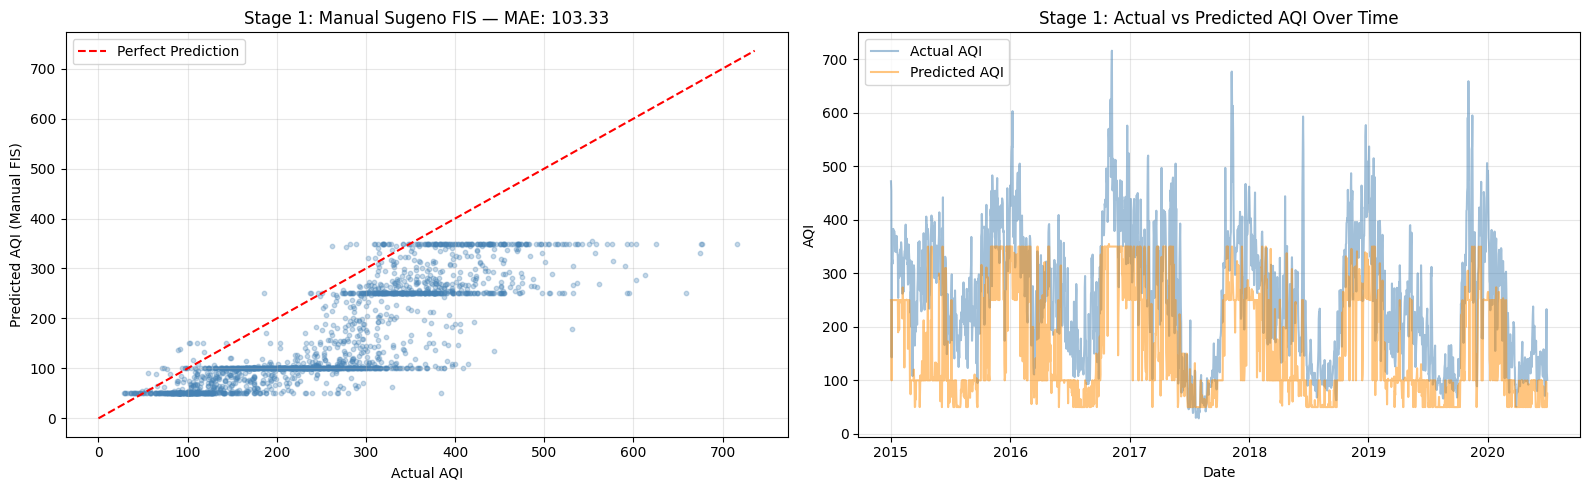

In [18]:
# Run
aqi_df = load_all_data()
print(f'Cleaned data points (All Cities): {len(aqi_df)}')
aqi_df, mae = run_stage1_inference(aqi_df)
plot_stage1_results(aqi_df, mae)